# **Statistical Arbitrage - Pairs Trading**

## **Theory**

### **From Arbitrage to Statistical Arbitrage**

At its core, **arbitrage** means exploiting price discrepancies between identical or similar assets to earn a *risk-free* profit.
In reality, truly risk-free opportunities are rare and short-lived. So, traders began extending the idea probabilistically: instead of guaranteed profits, they seek **expected** profits with **controlled risk** - this is **statistical arbitrage (stat-arb)**.

**Statistical arbitrage** is a quantitative trading strategy that uses statistical models to identify mispricings between related securities. It’s based not on perfect replication (as in classical arbitrage) but on the statistical expectation that price relationships will revert to some equilibrium over time. 
The key ingredients are:

* **A model** for the “fair” relationship between asset prices.
* **A deviation measure** (how far the actual prices stray from that model).
* **A trading rule** to exploit mean reversion.

The simplest and most famous form of stat-arb is **pairs trading**.

---

### **Pairs Trading: The Intuition**

In **pairs trading**, we pick two assets (say, two stocks in the same sector) whose prices tend to move together - perhaps Shell and BP.

1. We monitor their *relative price* - for example, the price difference or a linear combination $S_t = P_{1,t} - \beta P_{2,t}$.
2. When this spread deviates “too far” from its historical average, we bet on *convergence*:

   * Go long the underperformer (buy it).
   * Go short the outperformer (sell it).
3. When the spread returns to normal, we close both positions, ideally making a profit.

This relies on **mean reversion** - the assumption that relative prices don’t drift apart indefinitely but fluctuate around some equilibrium relationship.

But how can we **verify** whether two price series are genuinely tied together in the long run?
That’s where **cointegration** comes in.

---

### **Cointegration: The Statistical Foundation**

Most financial time series, like stock prices, are **non-stationary** - they follow something like a random walk.
That means they can drift arbitrarily far from their initial value, and standard correlation is unreliable because the level of the series doesn’t have a stable mean or variance.

However, sometimes two non-stationary series move *together* in such a way that a particular linear combination is **stationary** (mean-reverting).
Formally, if:
$$
X_t \sim I(1), \quad Y_t \sim I(1),
$$
but there exists some ($\beta$) such that:
$$
Z_t = Y_t - \beta X_t \sim I(0),
$$
then ($X_t$) and ($Y_t$) are **cointegrated** with cointegrating vector $(1, -\beta)$.

In words: although each price series wanders, their long-run equilibrium relation keeps them tethered.
The deviation $Z_t$ is the “spread” - the variable we expect to revert to its mean. This is the signal that drives a pairs trade.

---

### **Testing and Modeling Cointegration**

Several tools exist to detect and exploit cointegration:

* **Engle–Granger two-step test**:

  1. Regress $Y_t$ on $X_t$ to estimate $\hat{\beta}$.
  2. Test residuals $Z_t = Y_t - \hat{\beta} X_t$ for stationarity using, e.g., the Augmented Dickey-Fuller (ADF) test.

* **Johansen test**:
  For multiple assets, it finds the rank and cointegrating relationships within a vector error-correction model (VECM).

If cointegration holds, we can model the short-run deviations using:
$$
\Delta Y_t = \alpha (Y_{t-1} - \beta X_{t-1}) + \varepsilon_t,
$$
where $\alpha$ measures the **speed of adjustment** back to equilibrium.

---

### **From Cointegration to Trading**

Once we have a stationary spread $Z_t = Y_t - \beta X_t$, we treat it as a *mean-reverting process*, often modeled as:
$$
dZ_t = \kappa (\mu - Z_t)dt + \sigma dW_t,
$$
where:

* $\kappa$: mean-reversion speed,
* $\mu$: long-run mean (usually zero),
* $\sigma$: volatility of the spread.

The trading rule is straightforward:

* Go **long** when $Z_t$ is below its mean (expect it to rise).
* Go **short** when $Z_t$ is above its mean (expect it to fall).
* Close the position when $Z_t$ reverts.

Profit comes not from predicting direction, but from betting on *relative convergence*.

In [11]:
# Import libaries -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from arch.unitroot import ADF
from arch.unitroot import PhillipsPerron
from itertools import combinations


## **Data**

In [12]:
# Import and prepare data -----

# Price data
dfPRICES = pd.read_csv('data/DJGT_prices.csv', index_col=0, parse_dates=True)

# Extract stock names 
lSTOCKS = dfPRICES.columns.tolist()

# Number of observations
iOBS = len(dfPRICES)

# Log prices
dfLOGPRICES = np.log(dfPRICES)

# Consituents info
dfCONSTITUENTS = pd.read_csv('data/DJGT_constituents.csv', index_col=0)


## **Engle–Granger Two-step Cointegration Test**

In [13]:
# Cointegration test for stock pairs –––––

# Initilize lists to store regression rows
lREG_ROWS = []
# Initilize dictionaries to store spreads and fitted values
dSPREAD = {}
dFITTED = {}

# Iterate through all possible pairs of stocks
for Y, X in combinations(lSTOCKS, 2):

    # Step I. Regression ---

    # Extract log price series for the pair
    sY = dfLOGPRICES[Y].to_numpy()
    sX = dfLOGPRICES[X].to_numpy()

    # OLS Regression: sY = ALPHA + BETA * sX + RESID
    sX = np.column_stack([np.ones_like(sX), sX])
    fALPHA, fBETA = np.linalg.lstsq(sX, sY, rcond=None)[0]

    # Calculate fitted values and residuals
    sFITTED = sX @ np.array([fALPHA, fBETA])
    sRESID = sY - sFITTED

    # Calculate R-squared
    fSS_RES = float(np.dot(sRESID, sRESID))
    sY_CENTERED = sY - sY.mean()
    fSS_TOT = float(np.dot(sY_CENTERED, sY_CENTERED))
    fR2 = np.nan if fSS_TOT == 0.0 else 1.0 - fSS_RES / fSS_TOT

    # lREG_ROWS.append({"Y": Y, "X": X, "ALPHA": float(fALPHA), "BETA": float(fBETA), "R2": fR2})

    strKEY = f"{Y}_on_{X}"
    dSPREAD[strKEY] = pd.Series(sRESID, index=dfLOGPRICES.index)
    dFITTED[strKEY] = pd.Series(sFITTED, index=dfLOGPRICES.index)


    # Step II. Spread Stationarity ---

    # Augmented Dickey-Fuller test
    testADF = ADF(sRESID)
    fADF_PVALUE = testADF.pvalue
    # Phillips-Perron test
    testPP = PhillipsPerron(sRESID)
    fPP_PVALUE = testPP.pvalue

    # Store results in the regression rows
    lREG_ROWS.append({"Y": Y, "X": X, "ALPHA": float(fALPHA), "BETA": float(fBETA), "R2": fR2, "ADF_pvalue": fADF_PVALUE, "PP_pvalue": fPP_PVALUE})



# Build DataFrames for regression results, spreads, and fitted values
dfREG_RESULTS = pd.DataFrame.from_records(lREG_ROWS, columns=["Y", "X", "ALPHA", "BETA", "R2", "ADF_pvalue", "PP_pvalue"])
dfREG_SPREAD = pd.DataFrame(dSPREAD)
dfREG_FITTED = pd.DataFrame(dFITTED)


### **Visualization**

In [14]:
# DataFrame for visualization

dfVIS = dfREG_RESULTS.copy()

# Ordering pairs based on cointegration test results
dfVIS["ORDER"] = dfVIS[["ADF_pvalue", "PP_pvalue"]].mean(axis=1)
dfVIS = dfVIS.sort_values("ORDER", ascending=False).reset_index(drop=True)

# Filter pairs based on spread size (only for visualization purposes)
dfVIS["Spread_max"] = dfVIS.apply(lambda row: dfREG_SPREAD[f"{row['Y']}_on_{row['X']}"].max(), axis=1)
dfVIS["Spread_min"] = dfVIS.apply(lambda row: dfREG_SPREAD[f"{row['Y']}_on_{row['X']}"].min(), axis=1)
dfVIS = dfVIS[(dfVIS["Spread_max"] <= 1) & (dfVIS["Spread_min"] >= -1)] # That are between 1 and -1

# Add observed/fitted logrpice min-max cols
iMinlogprice = 2
iMaxlogprice = 6
dfVIS["LogPrice_max"] = dfVIS.apply(lambda row: max(dfLOGPRICES[row["Y"]].max(), dfREG_FITTED[f"{row['Y']}_on_{row['X']}"].max()), axis=1)
dfVIS["LogPrice_min"] = dfVIS.apply(lambda row: min(dfLOGPRICES[row["Y"]].min(), dfREG_FITTED[f"{row['Y']}_on_{row['X']}"].min()), axis=1)
dfVIS = dfVIS[(dfVIS["LogPrice_max"] <= iMaxlogprice) & (dfVIS["LogPrice_min"] >= iMinlogprice)] # That are between 0 and 5

# R-squared filter (only for visualization purposes)
dfVIS["R2_change"] = dfVIS["R2"].diff().fillna(0)
# Keep between -0.15 and 0.15
dfVIS = dfVIS[(dfVIS["R2_change"] >= -0.15) & (dfVIS["R2_change"] <= 0.15)].reset_index(drop=True)

IndexError: single positional indexer is out-of-bounds

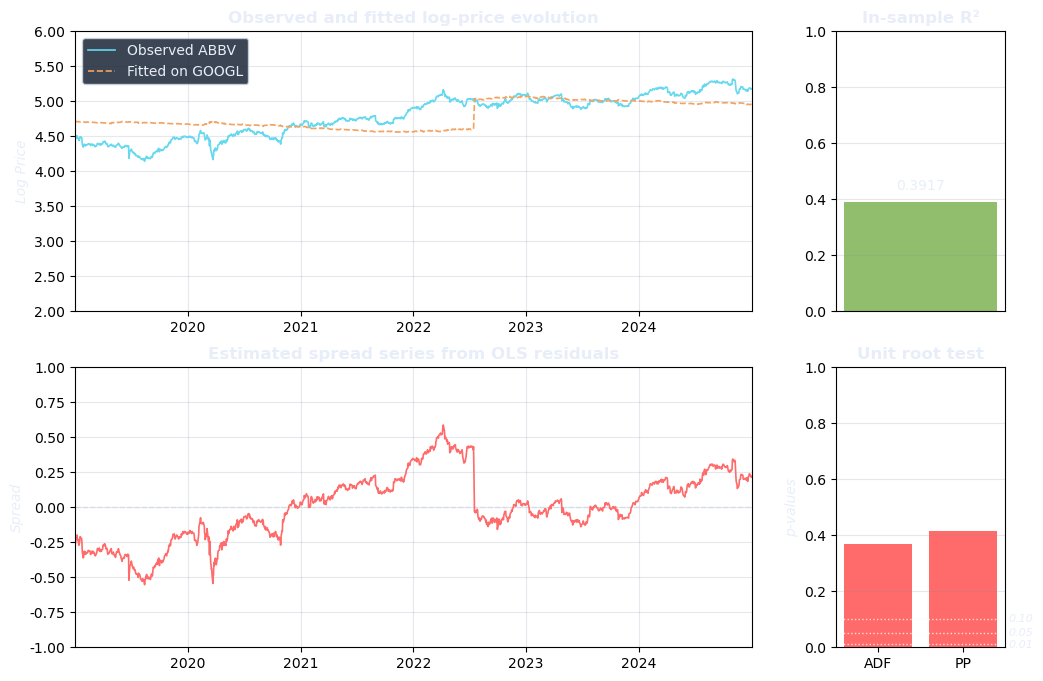

In [ ]:
# Create 2x2 diagnostic plots for every stock pair and save to /figs

# Custom dark theme colors
cFIG_BG = "#07111f"        # whole figure background
cAX_BG = "#0b1728"         # axes background
cTXT = "#e8eef9"           # main text color
cGRID = "#7f8ea3"          # muted grid color
cSPINE = "#cfd8e3"         # axis/frame color

cLINE_Y = "#66d9ef"        # cyan-like line for log price
cLINE_FITTED = "#f4a261"   # warm yellow for fitted series
cLINE_SPREAD = "#ff6b6b"   # pinkish spread line
cBAR_R2 = "#90be6d"        # green bar
# cBAR_ADF = "#ab9df2"       # purple bar
# cBAR_PP = "#f78c6c"        # orange bar
cTHRESHOLD = "#f8f8f2"     # significance line

# Helper function for p-value bar coloring
def get_pvalue_color(fPVALUE: float) -> str:
    
    if np.isnan(fPVALUE):
        return "#6c757d"   # muted grey for missing values
    
    if fPVALUE > 0.10:
        return "#ff6b6b"   # reddish = not significant at 10%
    elif fPVALUE > 0.05:
        return "#f4a261"   # orange-ish = borderline weak evidence
    elif fPVALUE > 0.01:
        return "#90be6d"   # light green = significant at 5%
    else:
        return "#2ecc71"   # stronger green = very significant

# Function to plot diagnostics for a given pair
def plot_pair_diagnostics(iITER, sROW, save_fig=False, print_fig=False) -> None:

    # Extract pair info
    sY = sROW["Y"]
    sX = sROW["X"]
    strKEY = f"{sY}_on_{sX}"

    # Pull series needed for plots ---
    # Plot 00 (top-left): Y logprice and regressed (fitted) Y on X
    sY_logprices = dfLOGPRICES[sY]
    sY_fitted = dfREG_FITTED[strKEY]

    # Plot 01 (top-right): Spread (residuals)
    sSpread = dfREG_SPREAD[strKEY]

    # Plot 10 (bottom-left): R2
    fR2 = float(sROW["R2"])

    # Plot 11 (bottom-right): p-values
    fADF_PVALUE = float(sROW["ADF_pvalue"])
    fPP_PVALUE = float(sROW["PP_pvalue"])

    # Build 2x2 figure ---
    fig, ax = plt.subplots(2, 2, figsize=(12, 8), dpi=100, gridspec_kw={'width_ratios': [4, 1]})

    # Plot 00 (top-left): Y logprice + fitted Y (regressed on X) -
    ax[0, 0].plot(sY_logprices.index, sY_logprices.values, label=f"Observed {sY}", linewidth=1.2, color=cLINE_Y)
    ax[0, 0].plot(sY_fitted.index, sY_fitted.values, label=f"Fitted on {sX}", linewidth=1.2, linestyle="--", color=cLINE_FITTED)
    ax[0, 0].set_title("Observed and fitted log-price evolution", color=cTXT, fontsize=12, fontweight="bold")
    ax[0, 0].set_ylabel("Log Price", color=cTXT, style="italic")
    ax[0, 0].grid(True, alpha=0.20, color=cGRID)
    ax[0, 0].legend(loc="upper left", facecolor=cAX_BG, edgecolor=cSPINE, labelcolor=cTXT)
    ax[0, 0].set_ylim(iMinlogprice, iMaxlogprice)
    ax[0, 0].set_xlim(sY_logprices.index.min(), sY_logprices.index.max())
    ax[0, 0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))


    # Plot 01 (top-right): single bar for R2 (0..1)
    r2_bar = 0.0 if np.isnan(fR2) else max(0.0, min(1.0, fR2))
    ax[0, 1].bar([0], [r2_bar], width=0.6, color=cBAR_R2)
    ax[0, 1].set_ylim(0, 1)
    ax[0, 1].set_xticks([])
    ax[0, 1].set_title("In-sample R²", color=cTXT, fontsize=12, fontweight="bold")
    ax[0, 1].grid(True, axis="y", alpha=0.20, color=cGRID)
    ax[0, 1].text(0, r2_bar + 0.03, f"{fR2:.4f}" if not np.isnan(fR2) else "NaN", ha="center", va="bottom", color=cTXT)


    # Plot 10 (bottom-left): Spread -
    ax[1, 0].axhline(0, color=cSPINE, linewidth=1.0, linestyle="--", alpha=0.7)
    cLINE_SPREAD = get_pvalue_color(fADF_PVALUE)
    ax[1, 0].plot(sSpread.index, sSpread.values, linewidth=1.2, color=cLINE_SPREAD)
    ax[1, 0].set_title("Estimated spread series from OLS residuals", color=cTXT, fontsize=12, fontweight="bold")
    ax[1, 0].set_ylabel("Spread", color=cTXT, style="italic")
    ax[1, 0].grid(True, alpha=0.20, color=cGRID)
    sSpread_max = np.ceil(np.abs(sSpread.values).max())
    ax[1, 0].set_ylim(-sSpread_max, sSpread_max)
    ax[1, 0].set_xlim(sSpread.index.min(), sSpread.index.max())
    ax[1, 0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))


    # Plot 11 (bottom-right): p-values (ADF + PP) (0..1) -
    pvals = [0.0 if np.isnan(fADF_PVALUE) else max(0.0, min(1.0, fADF_PVALUE)),
             0.0 if np.isnan(fPP_PVALUE) else max(0.0, min(1.0, fPP_PVALUE))]
    cBAR_ADF_DYNAMIC = get_pvalue_color(fADF_PVALUE)
    cBAR_PP_DYNAMIC = get_pvalue_color(fPP_PVALUE)
    ax[1, 1].bar(["ADF", "PP"], pvals, color=[cBAR_ADF_DYNAMIC, cBAR_PP_DYNAMIC])
    ax[1, 1].set_ylabel("p-values", color=cTXT, style="italic")
    ax[1, 1].set_ylim(0, 1)
    ax[1, 1].set_title("Unit root test", color=cTXT, fontsize=12, fontweight="bold")
    ax[1, 1].grid(True, axis="y", alpha=0.20, color=cGRID)
    # Common significance threshold line
    ax[1, 1].axhline(0.01, color=cTHRESHOLD, linewidth=1.0, linestyle=":", alpha=0.8)
    ax[1, 1].text(1.02, 0.01, "0.01", transform=ax[1, 1].get_yaxis_transform(), va="center", color=cTXT, fontsize=8, style="italic")
    ax[1, 1].axhline(0.05, color=cTHRESHOLD, linewidth=1.0, linestyle=":", alpha=0.8)
    ax[1, 1].text(1.02, 0.05, "0.05", transform=ax[1, 1].get_yaxis_transform(), va="center", color=cTXT, fontsize=8, style="italic")
    ax[1, 1].axhline(0.1, color=cTHRESHOLD, linewidth=1.0, linestyle=":", alpha=0.8)
    ax[1, 1].text(1.02, 0.1, "0.10", transform=ax[1, 1].get_yaxis_transform(), va="center", color=cTXT, fontsize=8, style="italic")



    # Add constituent information table at the bottom -
    # Extract metadata for the two tickers
    sROW_Y = dfCONSTITUENTS[dfCONSTITUENTS["Ticker"] == sY].iloc[0]
    sROW_X = dfCONSTITUENTS[dfCONSTITUENTS["Ticker"] == sX].iloc[0]

    # Table content
    table_data = [[sROW_Y["Ticker"], sROW_Y["Corporation"], sROW_Y["Industry"], sROW_Y.name],
                  [sROW_X["Ticker"], sROW_X["Corporation"], sROW_X["Industry"], sROW_X.name]]

    # Column and row labels
    col_labels = ["Ticker", "Corporation", "Industry", "Country"]
    row_labels = ["Stock Y", "Stock X"]

    # Create table
    table = ax[1, 0].table(cellText=table_data, colLabels=col_labels, rowLabels=row_labels,
                            cellLoc="center",loc="bottom", bbox=[0.1, -0.4, 0.9, 0.2])

    # Style table for dark theme
    table.auto_set_font_size(False)
    table.set_fontsize(9)

    # Style table for dark theme
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor(cSPINE)
        cell.set_linewidth(0.35) # thinner borders
        cell.set_facecolor(cAX_BG)
        cell.get_text().set_color(cTXT)
        if row == 0 or col == -1: # column headers or row labels
            cell.get_text().set_fontweight("bold") # set to bold


    # Layout setup -
    # fig.tight_layout()

    # Apply dark theme to figure and all subplots
    fig.patch.set_facecolor(cFIG_BG)
    for row in ax:
        for a in row:
            a.set_facecolor(cAX_BG)
            a.tick_params(colors=cTXT)
            for spine in a.spines.values():
                spine.set_color(cSPINE)

    # Title for the whole figure
    fig.suptitle("Cointegration diagnostics for candidate stock pairs\nPrice fit, residual spread, and stationarity evidence",
                 y=1.03, fontsize=16, fontweight="bold", color=cTXT)
    
    # 
    #fig.subplots_adjust(bottom=0.0)

    # Save and/or show the figure
    if save_fig:
        fig.savefig(f"figs/{iITER}-pairs-{sY_logprices.name}-on-{sX}.png",bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)
    if print_fig:
        plt.show()

    return None


# Iterate over all regression results
for iITER, sROW in dfVIS.iterrows():
    plot_pair_diagnostics(iITER, sROW, save_fig=True, print_fig=False)

# Plot diagnostics for the first pair
iITER, sROW = next(dfVIS.iterrows())
plot_pair_diagnostics(iITER, sROW, save_fig=False, print_fig=True)

In [ ]:
dfCONSTITUENTS.head()

,Corporation,Ticker,Industry
Country,,,
United States,3M,MMM,Industrial Goods
United States,AbbVie,ABBV,Pharmaceutical
Germany,Allianz,ALV,Insurance
United States,Alphabet,GOOG,Technology
United States,Amazon,AMZN,Technology


## **Johansen Cointegration Test**
>**Work In Progress**

## **Trading**